## PROJET : Système de détection des fausses et vraies informations(Fake News Detection System)
### Description du projet
Ce projet vise à développer un système capable de détecter les fausses informations (fake news) en utilisant des techniques d'apprentissage automatique et de traitement du langage naturel. Le système analysera des articles, des publications sur les réseaux sociaux et d'autres sources d'information pour évaluer leur véracité.
### Objectifs
1. **Collecte de données** : Rassembler un ensemble de données comprenant des articles étiquetés comme vrais ou faux.
2. **Prétraitement des données** : Nettoyer et préparer les données pour l'analyse, y compris la tokenisation, la suppression des stop words et la normalisation.
3. **Exploration des données** : Analyser les données pour identifier les caractéristiques clés qui peuvent aider à distinguer les fausses informations des vraies.
4. **Modélisation** : Développer et entraîner des modèles d'apprentissage automatique pour classer les articles comme vrais ou faux.
5. **Évaluation** : Évaluer les performances des modèles en utilisant des métriques appropriées telles que la précision, le rappel et la F-mesure.
6. **Déploiement** : Mettre en place une interface utilisateur pour permettre aux utilisateurs de soumettre des articles et de recevoir une évaluation de leur véracité.
### Technologies et outils
- **Langages de programmation** : Python
- **Bibliothèques** : Scikit-learn, NLTK, Pandas, NumPy, Matplotlib
- **Frameworks de machine learning** : TensorFlow, Keras
- **Base de données** : SQLite ou MongoDB pour stocker les articles et leurs étiquettes
- **Environnement de développement** : Jupyter Notebook ou PyCharm

### Résultats attendus
- Un système capable de classer les articles comme vrais ou faux avec une précision acceptable.
- Une interface utilisateur fonctionnelle permettant aux utilisateurs de soumettre des articles.
- Un rapport détaillant les performances du modèle et les défis rencontrés lors du développement.

#### Importation des bibliothèques nécessaires
```python


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, accuracy_score, adjusted_rand_score, precision_recall_curve, roc_auc_score, roc_curve, recall_score,f1_score, precision_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
# Suppress warnings for cleaner output
import warnings, re, os, sys


warnings.filterwarnings("ignore")

#### Loading the dataset et Transformation the files .tsv to .csv

In [5]:
def load_dataset(file_path):
    try:
        data = pd.read_csv(file_path)
        return data
    except :
        raise
    
fake = '../Data_collect/Dataset/Fake_data.csv'
true = '../Data_collect/Dataset/True_data.csv'

### Display of data (fake, train, true)

In [5]:
data_fake = load_dataset(fake)
data_true = load_dataset(true)

In [6]:
data_true.head()

,text,label,text_news
0,China's Honor launches new challenge to Samsun...,1,Unknown
1,European heat wave closes Eiffel Tower’s top f...,1,Unknown
2,"US pauses some munitions shipments to Ukraine,...",1,Unknown
3,"Democrats, the last holdout bears, could be th...",1,Unknown
4,CBS owner Paramount settles Trump lawsuit over...,1,Unknown


In [7]:
data_fake.head()

,text_fake,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0


#### Description of the dataset

In [8]:
print("Fake News Dataset Shape:", data_fake.shape)
print("True News Dataset Shape:", data_true.shape)

Fake News Dataset Shape: (23481, 2)
True News Dataset Shape: (22142, 3)


In [9]:
data_true.describe(include='all')

,text,label,text_news
count,22142,22142.0,22142
unique,114,NaN,21198
top,What happens to Sean Combs now? - NPRThis repo...,NaN,Unknown
freq,21446,NaN,725
mean,NaN,1.0,NaN
std,NaN,0.0,NaN
min,NaN,1.0,NaN
25%,NaN,1.0,NaN
50%,NaN,1.0,NaN
75%,NaN,1.0,NaN


In [10]:
data_fake.describe(include='all')

,text_fake,label
count,23481,23481.0
unique,17908,NaN
top,ELEMENTARY SCHOOL PLANS ‘BLACKS ONLY’ FIELD TR...,NaN
freq,4,NaN
mean,NaN,0.0
std,NaN,0.0
min,NaN,0.0
25%,NaN,0.0
50%,NaN,0.0
75%,NaN,0.0


In [11]:
print(f""" Informations on true_news_collected {data_true.info()}\n
    the informations of fake dataset {data_fake.info()}""")
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22142 entries, 0 to 22141
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       22142 non-null  object
 1   label      22142 non-null  int64 
 2   text_news  22142 non-null  object
dtypes: int64(1), object(2)
memory usage: 519.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text_fake  23481 non-null  object
 1   label      23481 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 367.0+ KB
 Informations on true_news_collected None

    the informations of fake dataset None


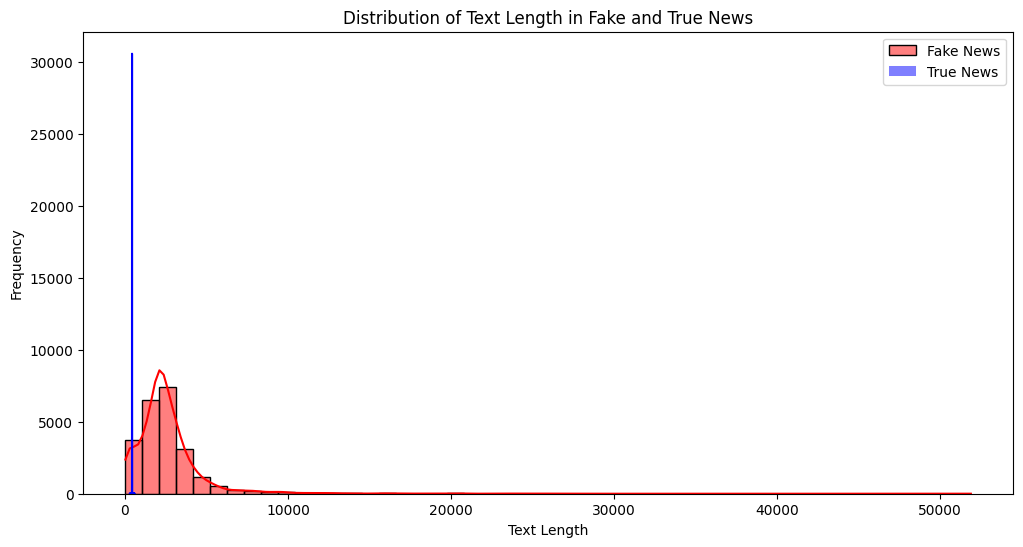

In [12]:
## count the length of the text in the fake and true news datasets
datafake_copy = data_fake.copy()
datatrue_copy = data_true.copy()
datafake_copy['text_length'] = datafake_copy['text_fake'].apply(lambda x: len(str(x)))
datatrue_copy['text_length'] = datatrue_copy['text'].apply(lambda x: len(str(x)))

# Plotting the distribution of text length in fake and true news datasets
plt.figure(figsize=(12, 6))
sns.histplot(datafake_copy['text_length'], bins=50, color='red', label='Fake News', kde=True)
sns.histplot(datatrue_copy['text_length'], bins=50, color='blue', label='True News', kde=True)

plt.title('Distribution of Text Length in Fake and True News')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

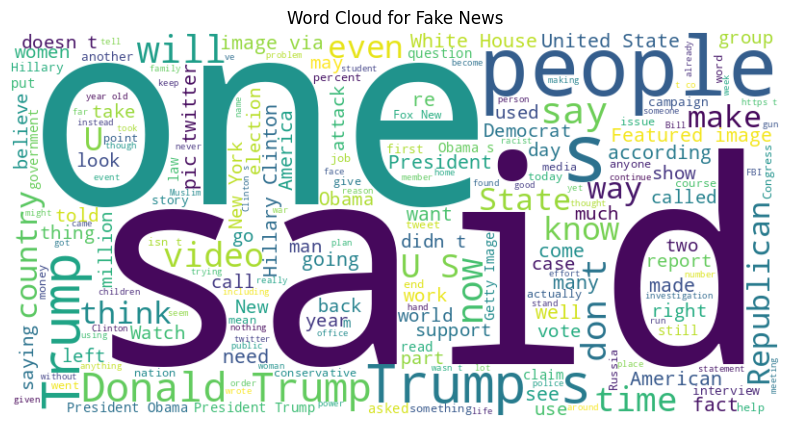

In [13]:
import wordcloud
from wordcloud import WordCloud, STOPWORDS
def plot_wordcloud(data, title):
    text = ' '.join(data['text_fake'].astype(str).tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

plot_wordcloud(data_fake, 'Word Cloud for Fake News')

#### Attributes the labels on each article

In [15]:
## conbined the title, content and description for doing the one_columns text

data_true['text_true'] = data_true['text'] + "" + data_true['text_news']
# supprimers les colonnes text and text_news
data_true = data_true.drop(columns=['text', 'text_news'], axis=1)
data_true.head()

,label,text_true
0,1,China's Honor launches new challenge to Samsun...
1,1,European heat wave closes Eiffel Tower’s top f...
2,1,"US pauses some munitions shipments to Ukraine,..."
3,1,"Democrats, the last holdout bears, could be th..."
4,1,CBS owner Paramount settles Trump lawsuit over...


In [16]:
data_true.shape, data_fake.shape

((22142, 2), (23481, 2))

``` text
#### Merge the dataset "data_true" and "data_fake"

```

In [17]:
df_true = data_true.rename(columns={"text_true":'text'})
df_false = data_fake.rename(columns={"text_fake":'text'})

# combined les deux datasets
df = pd.concat([df_true, df_false], axis=0).reset_index(drop=True)

df_final = df.sample(frac=1, random_state=80).reset_index(drop=True)

In [18]:
df_final["text"].isnull().sum()

np.int64(0)

In [19]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45623 entries, 0 to 45622
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   45623 non-null  int64 
 1   text    45623 non-null  object
dtypes: int64(1), object(1)
memory usage: 713.0+ KB


#### Save the dataset final who will be used to pre-training and modeling training

In [20]:
df_final.to_csv("../Data_cleaned/data_final.csv", index=False)

### Exploratory Data Analysis (EDA)

In [2]:
import string, re, nltk
from nltk.corpus import stopwords, wordnet
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))    

[nltk_data] Downloading package stopwords to /home/dona-
[nltk_data]     erick/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/dona-
[nltk_data]     erick/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
path = "../Data_cleaned/data_final.csv"
data = load_dataset(path)
## length of the text
data['text_length'] = data['text'].apply(lambda x: len(x.split()))
## statistqiues descriptives
print(f"Nombres d'articles : {len(data)}")
# Nombre de classe 
print(f"Nombre de classes : {data['label'].value_counts()}")
# groupement par label et analyse descriptives
print(data.groupby('label')['text_length'].describe())

Nombres d'articles : 45623
Nombre de classes : label
0    23481
1    22142
Name: count, dtype: int64
         count        mean         std   min    25%    50%    75%     max
label                                                                    
0      23481.0  436.995230  408.545659   1.0  253.0  377.0  520.0  8148.0
1      22142.0  454.652832  278.498413  45.0  209.0  431.0  596.0  5253.0


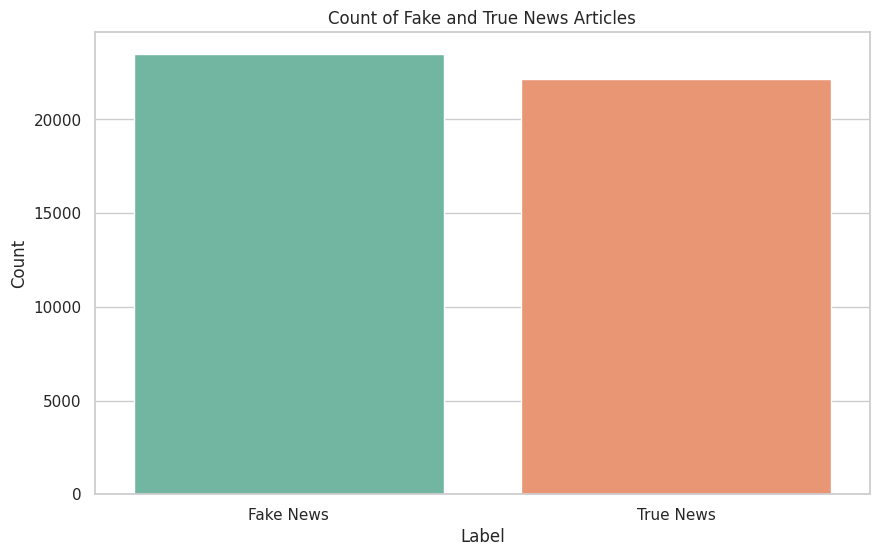

In [7]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=data, palette='Set2')
plt.title('Count of Fake and True News Articles')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Fake News', 'True News'])
plt.show()


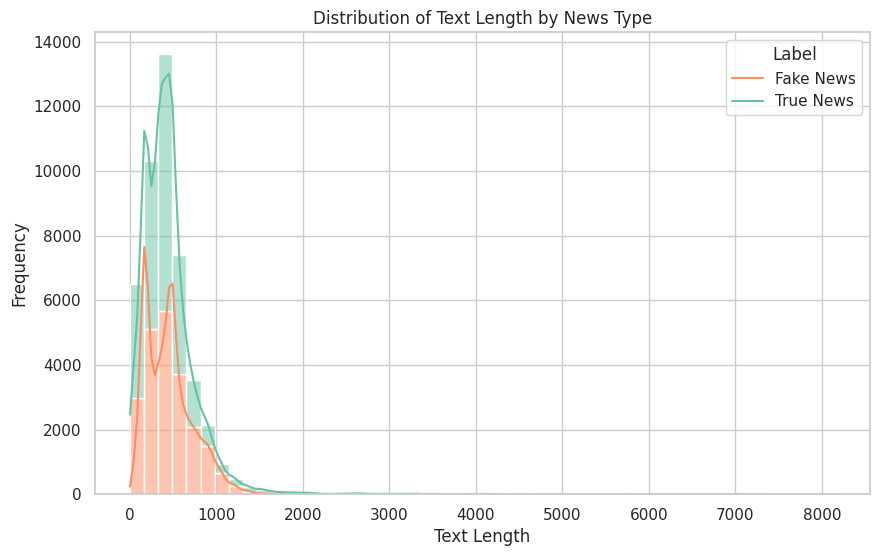

In [8]:
# Combine the datasets and add a label column
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='text_length', hue='label', multiple='stack', bins=50, palette='Set2', kde=True)
plt.title('Distribution of Text Length by News Type')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend(title='Label', labels=['Fake News', 'True News'])
plt.show()

## Nettoyage des textes

In [9]:
## nettoyage du texte
def clean_text(text):
    text = re.sub(r'\d+', '', text)  # Remove digits
    text = re.sub(r'<.*?>', '', text) ## Retire les balises HTML
    text = re.sub(r'http\S+|www\S+', '', text) # suppression des urls
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower()  # Convert to lowercase
    text = ''.join([c for c in text if c not in string.punctuation])  # Remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return ' '.join(tokens)

data['cleaned_text'] = data['text'].apply(clean_text)
# Display the first few rows of the cleaned text
print(data[['text', 'cleaned_text']].head())

                                                text  \
0  What happens to Sean Combs now? - NPRThis repo...   
1  What happens to Sean Combs now? - NPRThis repo...   
2  What happens to Sean Combs now? - NPRThis repo...   
3   SIX Republican Lawmakers Have Quietly Met Wit...   
4   This HORRIFYING List Is Exactly Why We Can’t ...   

                                        cleaned_text  
0  happens sean combs nprthis report mentions phy...  
1  happens sean combs nprthis report mentions phy...  
2  happens sean combs nprthis report mentions phy...  
3  six republican lawmakers quietly met bundy mil...  
4  horrifying list exactly cant say okay trumptwo...  


#### Nuages des mots des fake_news et des vrais news après le nettoyage des données

In [ ]:
## des fakes news
def plot_wordcloud(data, title):
    text = ' '.join(data['text'].astype(str).tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

print("WordCloud for Fake News (Cleaned)")
plot_wordcloud(data[data['label'] == 0], 'Word Cloud for Fake News (Cleaned)')

# True news
print("WordCloud for True News (Cleaned)")
plot_wordcloud(data[data['label'] == 1], 'Word Cloud for True News (Cleaned)')

WordCloud for Fake News (Cleaned)


#### Analyse semantiques

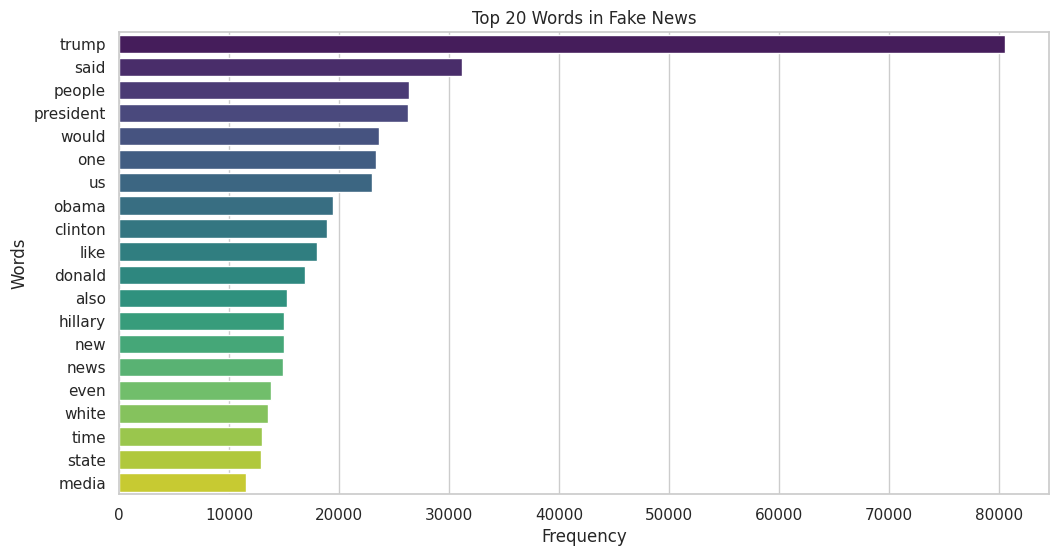

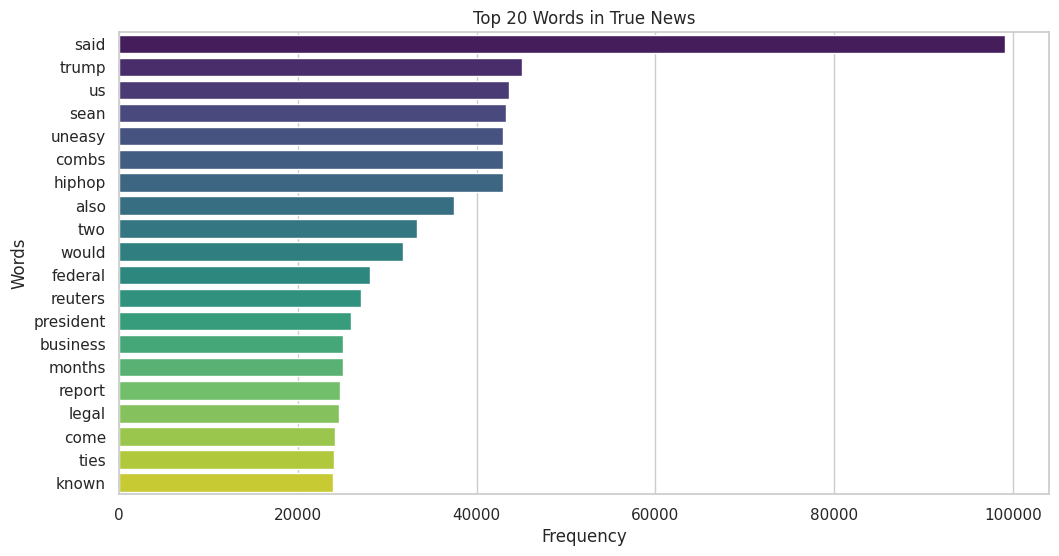

In [10]:
from collections import Counter # Count the frequency of words in the cleaned text
def analyse_semantic(text):
    text = text.lower()  # Convert to lowercase
    text = ''.join([c for c in text if c not in string.punctuation])  # Remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    return tokens

df = data.copy()
df['tokens'] = df['cleaned_text'].apply(lambda x: analyse_semantic(x))

# counter des mots pour identifier les mots les plus frequents dans les fake news et les true news
fake_words = [word for tokens in df[df['label'] == 0]['tokens'] for word in tokens]
true_words = [word for tokens in df[df['label'] == 1]['tokens'] for word in tokens]
fake_word_counts = Counter(fake_words)
true_word_counts = Counter(true_words)


def plot_top_words(word_counts, title, n=20):
    words, counts =zip(*word_counts.most_common(n))
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(title)
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

# Plotting the top 20 words in fake and true news
plot_top_words(fake_word_counts, 'Top 20 Words in Fake News', n=20)
plot_top_words(true_word_counts, 'Top 20 Words in True News', n=20)

In [11]:
data.tail(10)

,label,text,text_length,cleaned_text
45613,1,Qantas cyber hack could have stolen ‘significa...,74,qantas cyber hack could stolen significant amo...
45614,1,What happens to Sean Combs now? - NPRThis repo...,118,happens sean combs nprthis report mentions phy...
45615,0,Racist Donald Trump Actually Has The NERVE To...,309,racist donald trump actually nerve speak march...
45616,0,IT BEGINS: Wisconsin Company First in US to Im...,390,begins wisconsin company first us implant micr...
45617,1,What happens to Sean Combs now? - NPRThis repo...,748,happens sean combs nprthis report mentions phy...
45618,1,What happens to Sean Combs now? - NPRThis repo...,425,happens sean combs nprthis report mentions phy...
45619,0,BRILLIANT! P.J. O’ROURKE Casts His Vote For Th...,1044,brilliant pj orourke casts vote winner preside...
45620,1,What happens to Sean Combs now? - NPRThis repo...,402,happens sean combs nprthis report mentions phy...
45621,0,Is This Dem Senator Switching Parties? Calls O...,361,dem senator switching parties calls nfl owners...
45622,1,What happens to Sean Combs now? - NPRThis repo...,329,happens sean combs nprthis report mentions phy...


#### Save the cleaned dataset

```
Dataset Save with Unbalanced Classes

```

In [12]:
data = data[['text', 'cleaned_text', 'label']]

data.to_csv('../Data_cleaned/data_cleaned.csv', index=False)
print("Cleaned dataset saved to 'cleaned_news_dataset.csv'.")

Cleaned dataset saved to 'cleaned_news_dataset.csv'.


```
Balancing Dataset 

```